In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader # Corrected import statement

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt

In [2]:
iris=load_iris()

In [3]:
X=iris.data
y=iris.target.reshape(-1,1)

print(X.shape, y.shape)

(150, 4) (150, 1)


In [4]:
X_train,X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=42)

In [6]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
#

In [7]:
#convert data to pytorch tensors
X_train_tensor=torch.tensor(X_train, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train, dtype=torch.float32)

X_test_tensor=torch.tensor(X_test, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32)

In [8]:
class IrisDataset(Dataset):
  def __init__(self, X, y):
    self.X=X
    self.y=y

  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [10]:
train_dataset=IrisDataset(X_train_tensor, y_train_tensor)
test_dataset=IrisDataset(X_test_tensor, y_test_tensor)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64)

In [11]:
class RegressionDNN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.net(x)

model=RegressionDNN(input_dim=X_train.shape[1])
print(model)


RegressionDNN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [12]:
#loss function and optimizer
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
#training  loop
epochs=50
train_losses=[]

for epoch in range(epochs):
  model.train()
  epoch_loss=0.0

  for X_btach, y_batch in train_loader:
    optimizer.zero_grad()
    predictions=model(X_btach)
    loss=criterion(predictions, y_batch)
    loss.backward()
    optimizer.step()
    epoch_loss +=loss.item()


  avg_loss=epoch_loss/len(train_loader)
  train_losses.append(avg_loss)

  if (epoch+1)%10==0:
    print(f"Epoch[{epoch+1}/{epochs}]-loss:{avg_loss:.4f}")

Epoch[10/50]-loss:0.4054
Epoch[20/50]-loss:0.0747
Epoch[30/50]-loss:0.0455
Epoch[40/50]-loss:0.0407
Epoch[50/50]-loss:0.0360


<function matplotlib.pyplot.show(close=None, block=None)>

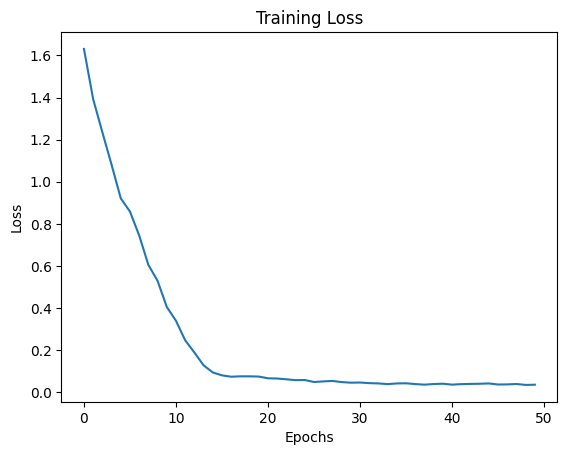

In [14]:
plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show

In [15]:
with torch.no_grad():
  y_pred=model(X_test_tensor).numpy()
  y_true=y_test_tensor.numpy()

mse=mean_squared_error(y_true, y_pred)
r2=r2_score(y_true, y_pred)
mae=mean_absolute_error(y_true, y_pred)

print(f"MSE:{mse:.2f}")
print(f"R2:{r2:.4f}")
print(f"MAE:{mae:.2F}")

MSE:0.04
R2:0.9450
MAE:0.12


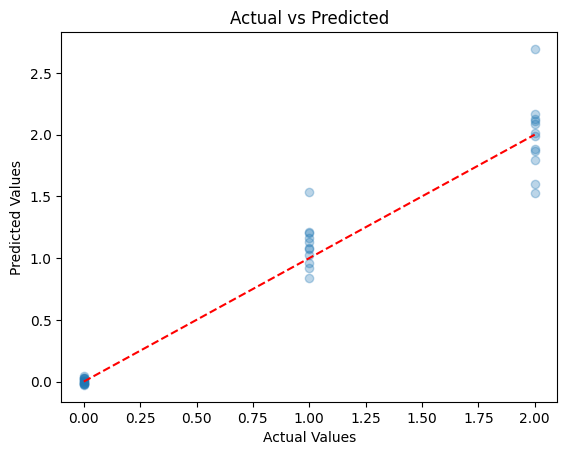

In [16]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()

plt.scatter(y_true, y_pred, alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()], 'r--')